# Space Reliability Index + Explainability


In [13]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Configurations


In [14]:
RAW_CSV_PATH = "burn_in_dataset.csv"
ANOMALY_RESULTS_PATH = "anomaly_results.csv"          # Module A output
DRIFT_MODEL_PATH = "drift_prediction_model.joblib"    # Module B output

METRICS = ['Leakage', 'Resistance', 'Vth']
CHECKPOINTS = ['0h', '24h', '96h', '168h']

# how much each signal contributes to the combined risk score
WEIGHT_ANOMALY = 0.5           # Module A's Anomaly_Risk_Score
WEIGHT_PREDICTED_DRIFT = 0.3   # Module B's forecasted 168h drift severity
WEIGHT_UNCERTAINTY = 0.2       # Module B's prediction interval width (low confidence -> more caution)

# tier boundaries on the final 0-100 risk score
RISK_SAFE_MAX = 30
RISK_BORDERLINE_MAX = 60

# a component that fails the absolute datasheet spec can't be called low-risk no
# matter what the other two signals say - same guardrail Module A uses internally
ABSOLUTE_FAIL_RISK_FLOOR = 65

# which parameter each proxy stress is expected to hit hardest
STRESS_PHYSICS = {
    'Thermal-High':   {'metric': 'Leakage',    'phrase': 'consistent with oxide/junction thermal degradation'},
    'Radiation-Low':  {'metric': 'Vth',        'phrase': 'consistent with radiation-induced charge trapping'},
    'Cycling-Medium': {'metric': 'Resistance', 'phrase': 'consistent with interconnect/contact fatigue'},
}

## Load everything

In [15]:
df = pd.read_csv(RAW_CSV_PATH)
anomaly = pd.read_csv(ANOMALY_RESULTS_PATH)
bundle = joblib.load(DRIFT_MODEL_PATH)

print(df.shape, 'raw rows')
print(anomaly.shape, 'anomaly results rows')
anomaly.head()

(10000, 25) raw rows
(10000, 12) anomaly results rows


,Component_ID,Batch_ID,Part_Type,Absolute_Spec_Fail,Lot_Relative_Score,Worst_Lot_Zscore,Multivariate_Score,Drift_Score,Anomaly_Risk_Score,QA_Decision,Label,Traditional_Test_Result
0,C501,ISRO-SCL-250421-16,MOSFET,0,12.6,1.01,9.8,3.1,9.6,PASS,Safe,Pass
1,C502,ISRO-SCL-250224-08,MOSFET,0,21.0,1.68,8.0,26.1,16.8,PASS,Borderline,Pass
2,C503,ISRO-SCL-250414-15,Digital Logic IC,0,100.0,9.02,38.6,7.1,56.8,MONITOR,Safe,Pass
3,C504,ISRO-SCL-250113-02,MOSFET,0,16.5,1.32,21.6,24.5,20.1,PASS,Borderline,Pass
4,C505,ISRO-SCL-250120-03,Op-Amp IC,1,14.1,1.13,15.2,10.4,85.0,REJECT,Safe,Fail


## Re-run Module B's feature pipeline

Need fresh predictions for every row, not just the ones that happened to land in Module B's
test set - same cleaning/feature steps as that notebook, reusing the saved imputer so nothing
is refit on this data.

In [16]:
feature_cols_raw = bundle['feature_cols_raw']

reading_cols = [f'{m}_{cp}' for m in METRICS for cp in CHECKPOINTS]
for col in reading_cols:
    df.loc[df[col] < 0, col] = np.nan   # same sensor-fault handling as Module B

for cp in CHECKPOINTS:
    df[f'Timestamp_{cp}'] = pd.to_datetime(df[f'Timestamp_{cp}'], format='ISO8601')
df['elapsed_24h'] = (df['Timestamp_24h'] - df['Timestamp_0h']).dt.total_seconds() / 3600

df.loc[:, feature_cols_raw] = bundle['imputer'].transform(df[feature_cols_raw])

df['Leakage_slope'] = (df['Leakage_24h'] - df['Leakage_0h']) / df['elapsed_24h']
df['Resistance_slope'] = (df['Resistance_24h'] - df['Resistance_0h']) / df['elapsed_24h']
df['Vth_slope'] = (df['Vth_24h'] - df['Vth_0h']) / df['elapsed_24h']

feature_cols_num = feature_cols_raw + ['Stress_Level', 'elapsed_24h', 'Leakage_slope', 'Resistance_slope', 'Vth_slope']
X = pd.get_dummies(df[feature_cols_num + ['Proxy_Stress', 'Part_Type']], columns=['Proxy_Stress', 'Part_Type'])
X = X.reindex(columns=bundle['feature_columns'], fill_value=0)
X.shape

(10000, 18)

In [17]:
rf_pred = bundle['rf'].predict(X)
gb_pred = bundle['gb'].predict(X)
stacked_raw = bundle['meta_model'].predict(np.hstack([rf_pred, gb_pred]))
lower_raw = bundle['quantile_lower'].predict(X)
upper_raw = bundle['quantile_upper'].predict(X)

def reconstruct(raw):
    out = pd.DataFrame(index=df.index)
    out['Leakage_168h'] = np.expm1(raw[:, 1])
    out['Resistance_168h'] = df['Resistance_24h'].values + raw[:, 3]
    out['Vth_168h'] = df['Vth_24h'].values + raw[:, 5]
    return out

point = reconstruct(stacked_raw)
lower = reconstruct(lower_raw)
upper = reconstruct(upper_raw)

df['Pred_Leakage_168h'] = point['Leakage_168h']
df['Pred_Resistance_168h'] = point['Resistance_168h']
df['Pred_Vth_168h'] = point['Vth_168h']
df['Interval_Width_Leakage'] = (upper['Leakage_168h'] - lower['Leakage_168h']).clip(lower=0)
df['Interval_Width_Resistance'] = (upper['Resistance_168h'] - lower['Resistance_168h']).clip(lower=0)
df['Interval_Width_Vth'] = (upper['Vth_168h'] - lower['Vth_168h']).clip(lower=0)
df[['Pred_Leakage_168h','Pred_Resistance_168h','Pred_Vth_168h']].describe()

,Pred_Leakage_168h,Pred_Resistance_168h,Pred_Vth_168h
count,10000.000000,10000.000000,10000.000000
mean,1.254554,103.974644,1.228721
std,0.923610,5.947011,0.094716
min,0.169736,90.806160,0.820570
25%,0.639018,99.298515,1.154825
50%,1.038501,103.920881,1.229559
75%,1.549293,108.493938,1.304396
max,5.766760,128.530177,1.449111


## Turn predictions into two 0-100 scores

**Predicted_Drift_Score** - how much more drift is forecasted between now (24h) and 168h.


**Uncertainty_Score** - how wide the prediction interval is.

In [18]:
pred_leak_drift = ((df['Pred_Leakage_168h'] - df['Leakage_24h']) / df['Leakage_24h'].abs()).abs()
pred_res_drift = ((df['Pred_Resistance_168h'] - df['Resistance_24h']) / df['Resistance_24h'].abs()).abs()
pred_vth_drift = ((df['Pred_Vth_168h'] - df['Vth_24h']) / df['Vth_24h'].abs()).abs()
df['Predicted_Drift_Severity_raw'] = pd.concat([pred_leak_drift, pred_res_drift, pred_vth_drift], axis=1).max(axis=1)

bound = df['Predicted_Drift_Severity_raw'].quantile(0.99)
df['Predicted_Drift_Score'] = (df['Predicted_Drift_Severity_raw'].clip(upper=bound) / max(bound, 1e-9) * 100)

iw = df[['Interval_Width_Leakage', 'Interval_Width_Resistance', 'Interval_Width_Vth']]
iw_norm = iw / iw.quantile(0.99).clip(lower=1e-9)
df['Uncertainty_Score'] = (iw_norm.max(axis=1) * 100).clip(0, 100)

df[['Predicted_Drift_Score', 'Uncertainty_Score']].describe()

,Predicted_Drift_Score,Uncertainty_Score
count,10000.000000,10000.000000
mean,26.979540,35.642198
std,19.432757,20.078219
min,1.047977,17.773349
25%,13.242970,22.612078
50%,21.151333,27.231128
75%,34.360642,39.362700
max,100.000000,100.000000


## Combine with Module A

In [19]:
merged = anomaly.merge(
    df[['Component_ID', 'Predicted_Drift_Score', 'Uncertainty_Score', 'Proxy_Stress',
        'Leakage_0h', 'Leakage_24h', 'Resistance_0h', 'Resistance_24h', 'Vth_0h', 'Vth_24h']],
    on='Component_ID', how='inner'
)
print(f'{len(merged)} components matched between the two modules')
merged.head()

10000 components matched between the two modules


,Component_ID,Batch_ID,Part_Type,Absolute_Spec_Fail,Lot_Relative_Score,Worst_Lot_Zscore,Multivariate_Score,Drift_Score,Anomaly_Risk_Score,QA_Decision,Label,Traditional_Test_Result,Predicted_Drift_Score,Uncertainty_Score,Proxy_Stress,Leakage_0h,Leakage_24h,Resistance_0h,Resistance_24h,Vth_0h,Vth_24h
0,C501,ISRO-SCL-250421-16,MOSFET,0,12.6,1.01,9.8,3.1,9.6,PASS,Safe,Pass,6.898656,24.839627,Cycling-Medium,0.905,0.959,97.63,98.21,1.228,1.230
1,C502,ISRO-SCL-250224-08,MOSFET,0,21.0,1.68,8.0,26.1,16.8,PASS,Borderline,Pass,29.193954,37.300889,Radiation-Low,0.456,0.687,104.33,104.95,1.309,1.286
2,C503,ISRO-SCL-250414-15,Digital Logic IC,0,100.0,9.02,38.6,7.1,56.8,MONITOR,Safe,Pass,14.945020,82.762263,Cycling-Medium,0.895,1.019,107.58,107.97,1.183,1.254
3,C504,ISRO-SCL-250113-02,MOSFET,0,16.5,1.32,21.6,24.5,20.1,PASS,Borderline,Pass,21.433172,27.162381,Cycling-Medium,0.151,0.223,107.52,108.01,1.382,1.380
4,C505,ISRO-SCL-250120-03,Op-Amp IC,1,14.1,1.13,15.2,10.4,85.0,REJECT,Safe,Fail,18.932663,27.392854,Radiation-Low,0.581,0.699,92.52,93.47,1.168,1.154


In [20]:
merged['Space_Risk_Score'] = (
    WEIGHT_ANOMALY * merged['Anomaly_Risk_Score']
    + WEIGHT_PREDICTED_DRIFT * merged['Predicted_Drift_Score']
    + WEIGHT_UNCERTAINTY * merged['Uncertainty_Score']
)
merged['Space_Risk_Score'] = np.where(
    merged['Absolute_Spec_Fail'] == 1,
    np.maximum(merged['Space_Risk_Score'], ABSOLUTE_FAIL_RISK_FLOOR),
    merged['Space_Risk_Score']
)
merged['Space_Risk_Score'] = merged['Space_Risk_Score'].clip(0, 100).round(1)
merged['Space_Reliability_Index'] = (100 - merged['Space_Risk_Score']).round(1)

def tier(score):
    if score < RISK_SAFE_MAX:
        return 'Space-Safe'
    if score < RISK_BORDERLINE_MAX:
        return 'Borderline'
    return 'High-Risk'

merged['Reliability_Tier'] = merged['Space_Risk_Score'].apply(tier)
merged['Reliability_Tier'].value_counts()

,count
Reliability_Tier,
Space-Safe,6420
High-Risk,2110
Borderline,1470


## Validation against Label



In [21]:
print(pd.crosstab(merged['Reliability_Tier'], merged['Label']))

fail_mask = merged['Label'] == 'Fail'
caught_any = merged.loc[fail_mask, 'Reliability_Tier'].isin(['Borderline', 'High-Risk']).mean()
caught_highrisk = merged.loc[fail_mask, 'Reliability_Tier'].eq('High-Risk').mean()
print(f'\nRecall on true FAIL, flagged Borderline or High-Risk: {caught_any:.1%}')
print(f'Recall on true FAIL, flagged High-Risk specifically:    {caught_highrisk:.1%}')

Label             Borderline  Fail  Safe
Reliability_Tier                        
Borderline               620   563   287
High-Risk                275   972   863
Space-Safe               944   149  5327

Recall on true FAIL, flagged Borderline or High-Risk: 91.2%
Recall on true FAIL, flagged High-Risk specifically:    57.7%


## Explainability


In [22]:
_pct_change = lambda v0, v24: (v24 - v0).abs() / v0.abs().clip(lower=1e-6)
_typical_scale = {
    'Leakage': _pct_change(df['Leakage_0h'], df['Leakage_24h']).quantile(0.95),
    'Resistance': _pct_change(df['Resistance_0h'], df['Resistance_24h']).quantile(0.95),
    'Vth': _pct_change(df['Vth_0h'], df['Vth_24h']).quantile(0.95),
}

def dominant_metric(row):
    raw = {
        'Leakage': abs(row['Leakage_24h'] - row['Leakage_0h']) / max(abs(row['Leakage_0h']), 1e-6),
        'Resistance': abs(row['Resistance_24h'] - row['Resistance_0h']) / max(abs(row['Resistance_0h']), 1e-6),
        'Vth': abs(row['Vth_24h'] - row['Vth_0h']) / max(abs(row['Vth_0h']), 1e-6),
    }
    normalized = {m: raw[m] / max(_typical_scale[m], 1e-9) for m in raw}
    metric = max(normalized, key=normalized.get)
    return metric, raw[metric]


def explain(row):
    metric, pct = dominant_metric(row)
    stress = row['Proxy_Stress']
    physics = STRESS_PHYSICS.get(stress, {'metric': None, 'phrase': 'stress mechanism not mapped'})

    if physics['metric'] == metric:
        physics_note = physics['phrase']
    else:
        physics_note = f"atypical for {stress} (usually hits {physics['metric']}) - worth a second look"

    parts = [f"{row['Reliability_Tier']}."]
    parts.append(f"{metric} moved {pct:.1%} in the first 24h under {stress} -> {physics_note}.")
    if row['Absolute_Spec_Fail'] == 1:
        parts.append('Failed traditional fixed-limit spec check.')
    if row['Worst_Lot_Zscore'] >= 2.0:
        parts.append(f"Batch-relative outlier (z={row['Worst_Lot_Zscore']:.2f} vs its own lot).")
    if row['Predicted_Drift_Score'] >= 50:
        parts.append('Forecast to 168h shows continued significant drift.')
    if row['Uncertainty_Score'] >= 60:
        parts.append('Forecast confidence is low - recommend extended monitoring rather than trusting the point estimate.')
    return ' '.join(parts)

merged['Explainability_Reason'] = merged.apply(explain, axis=1)
print('done')

done


In [23]:
print('=== sample High-Risk explanations ===\n')
for _, row in merged[merged['Reliability_Tier'] == 'High-Risk'].head(5).iterrows():
    print(row['Component_ID'], '-', row['Explainability_Reason'])
    print()

=== sample High-Risk explanations ===

C505 - High-Risk. Resistance moved 1.0% in the first 24h under Radiation-Low -> atypical for Radiation-Low (usually hits Vth) - worth a second look. Failed traditional fixed-limit spec check.

C515 - High-Risk. Resistance moved 0.5% in the first 24h under Cycling-Medium -> consistent with interconnect/contact fatigue. Failed traditional fixed-limit spec check.

C525 - High-Risk. Vth moved 5.0% in the first 24h under Radiation-Low -> consistent with radiation-induced charge trapping. Failed traditional fixed-limit spec check. Batch-relative outlier (z=4.05 vs its own lot). Forecast to 168h shows continued significant drift. Forecast confidence is low - recommend extended monitoring rather than trusting the point estimate.

C526 - High-Risk. Vth moved 7.8% in the first 24h under Radiation-Low -> consistent with radiation-induced charge trapping. Failed traditional fixed-limit spec check. Batch-relative outlier (z=5.78 vs its own lot). Forecast to 16

In [24]:
print('=== sample Space-Safe explanations, for contrast ===\n')
for _, row in merged[merged['Reliability_Tier'] == 'Space-Safe'].head(3).iterrows():
    print(row['Component_ID'], '-', row['Explainability_Reason'])
    print()

=== sample Space-Safe explanations, for contrast ===

C501 - Space-Safe. Resistance moved 0.6% in the first 24h under Cycling-Medium -> consistent with interconnect/contact fatigue.

C502 - Space-Safe. Leakage moved 50.7% in the first 24h under Radiation-Low -> atypical for Radiation-Low (usually hits Vth) - worth a second look.

C504 - Space-Safe. Leakage moved 47.7% in the first 24h under Cycling-Medium -> atypical for Cycling-Medium (usually hits Resistance) - worth a second look.



## Quick look: score distribution

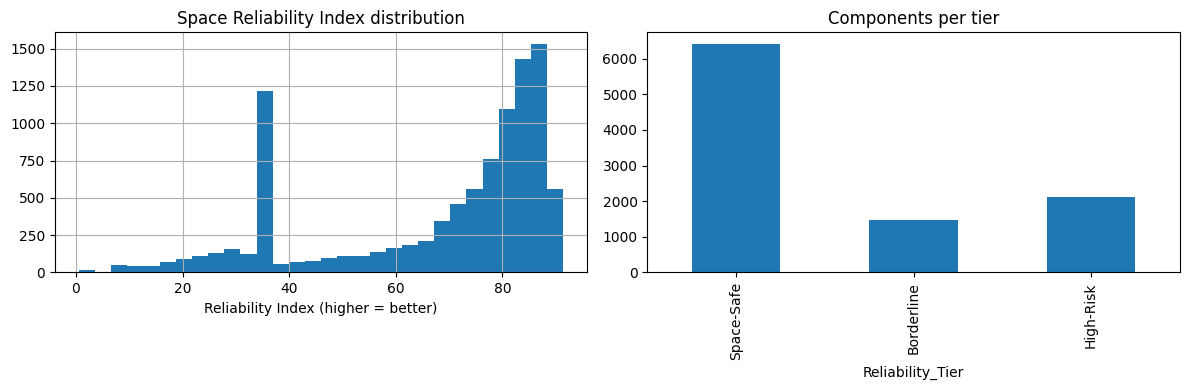

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
merged['Space_Reliability_Index'].hist(bins=30, ax=axes[0])
axes[0].set_title('Space Reliability Index distribution')
axes[0].set_xlabel('Reliability Index (higher = better)')

merged['Reliability_Tier'].value_counts().reindex(['Space-Safe','Borderline','High-Risk']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Components per tier')
plt.tight_layout()
plt.show()

## Final output table

In [26]:
final_cols = [
    'Component_ID', 'Batch_ID', 'Part_Type', 'Proxy_Stress',
    'Anomaly_Risk_Score', 'Predicted_Drift_Score', 'Uncertainty_Score',
    'Space_Risk_Score', 'Space_Reliability_Index', 'Reliability_Tier',
    'Explainability_Reason', 'Label', 'Traditional_Test_Result',
]
final = merged[final_cols].sort_values('Space_Risk_Score', ascending=False)
final.head(10)

,Component_ID,Batch_ID,Part_Type,Proxy_Stress,Anomaly_Risk_Score,Predicted_Drift_Score,Uncertainty_Score,Space_Risk_Score,Space_Reliability_Index,Reliability_Tier,Explainability_Reason,Label,Traditional_Test_Result
1238,C1739,ISRO-SCL-250512-19,Op-Amp IC,Thermal-High,98.9,100.000000,100.0,99.4,0.6,High-Risk,High-Risk. Leakage moved 234.3% in the first 2...,Fail,Fail
5881,C6382,ISRO-SCL-250414-15,Digital Logic IC,Radiation-Low,98.4,100.000000,100.0,99.2,0.8,High-Risk,High-Risk. Resistance moved 7.0% in the first ...,Fail,Fail
3602,C4103,ISRO-SCL-250414-15,Digital Logic IC,Cycling-Medium,97.1,100.000000,100.0,98.6,1.4,High-Risk,High-Risk. Resistance moved 8.9% in the first ...,Fail,Fail
1043,C1544,ISRO-SCL-250217-07,Op-Amp IC,Radiation-Low,96.7,100.000000,100.0,98.4,1.6,High-Risk,High-Risk. Vth moved 13.0% in the first 24h un...,Fail,Fail
6890,C7391,ISRO-SCL-250120-03,Op-Amp IC,Cycling-Medium,96.4,100.000000,100.0,98.2,1.8,High-Risk,High-Risk. Resistance moved 8.4% in the first ...,Fail,Fail
1738,C2239,ISRO-SCL-250407-14,MOSFET,Thermal-High,99.3,93.161365,100.0,97.6,2.4,High-Risk,High-Risk. Leakage moved 187.3% in the first 2...,Fail,Fail
3361,C3862,ISRO-SCL-250407-14,MOSFET,Thermal-High,94.7,100.000000,100.0,97.4,2.6,High-Risk,High-Risk. Resistance moved 3.3% in the first ...,Fail,Fail
3983,C4484,ISRO-SCL-250414-15,Digital Logic IC,Thermal-High,94.9,100.000000,100.0,97.4,2.6,High-Risk,High-Risk. Resistance moved 7.0% in the first ...,Fail,Fail
5292,C5793,ISRO-SCL-250407-14,MOSFET,Cycling-Medium,94.4,100.000000,100.0,97.2,2.8,High-Risk,High-Risk. Resistance moved 10.5% in the first...,Fail,Fail
1779,C2280,ISRO-SCL-250407-14,MOSFET,Thermal-High,94.4,100.000000,100.0,97.2,2.8,High-Risk,High-Risk. Leakage moved 457.9% in the first 2...,Fail,Fail


In [27]:
final.to_csv('space_reliability_index.csv', index=False)
print(f'saved {len(final)} rows to space_reliability_index.csv')

saved 10000 rows to space_reliability_index.csv
